In [67]:
import gemmi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import reciprocalspaceship as rs
from meteor import rsmap
from meteor.sfcalc import gemmi_structure_to_calculated_map
from configuration import load_homepath
from configuration import get_file_config
from logger import setup_logger
%load_ext autoreload
%autoreload 2
logger = setup_logger()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:

X8_path = load_homepath() + "X8_runs/gaussian_snr_10/"
X8_path = load_homepath() + "X8_runs/qsnr_100/"
X8_path = load_homepath() + "X8_runs/qsnr_10/"
X8_path = load_homepath() + "X8_runs/qsnr_25/"
X8_path = load_homepath() + "X8_runs/snr_25/"
X8_path = load_homepath() + "X8_runs/snr_100/"
X8_path = load_homepath() + "X8_runs/snr_10/"
X8_path = load_homepath() + "X8_runs/gaussian_snr_10/"
X8_path = load_homepath() + "X8_runs/gaussian_snr_5/"
X8_path = load_homepath() + "X8_runs/gaussian_snr_25/"
print("X8_path:", X8_path)
if ("q" in X8_path) or ("gaussian" in X8_path):
    diffmap_path = X8_path + "xx_mqFoFo.mtz"
    diffmap_columns = dict( amplitude_column="QFOFOWT", phase_column="PHIQFOFOWT")
else:
    diffmap_path = X8_path + "xx_mFoFo.mtz"
    diffmap_columns = dict( amplitude_column="FOFOWT", phase_column="PHIFOFOWT")
reference_mtz = load_homepath() + "/synthetic_cistrans/trans_snr_10_dmin_16.mtz"
triggered_mtz = load_homepath() + "/synthetic_cistrans/100ps_snr_10_dmin_16.mtz"
reference_pdb = load_homepath() + "/synthetic_cistrans/trans.pdb"
triggered_pdb = load_homepath() + "/synthetic_cistrans/100ps.pdb"
dmin = 1.6
name_machine = "sim_rsEFGP2"

col_dict = {
    "amplitude_column": "F_on",
    "phase_column": "PHIC",
    "uncertainty_column": "SIGF_on",
}
config = get_file_config(
    reference_mtz,
    triggered_mtz,
    reference_pdb,
    col_dict,
    col_dict,
    dmin,
    name_machine,
)
config["diffmap_path"] = diffmap_path

X8_path: /Users/sbielfel/Nextcloud2/time_resolved/X8_runs/gaussian_snr_25/


In [94]:

ds_dark = rs.read_mtz(reference_mtz)
struc_dark = gemmi.read_pdb(reference_pdb)
map_dark_comp = gemmi_structure_to_calculated_map(
    struc_dark, high_resolution_limit=dmin,
)
ds_dark["PHIC"] = map_dark_comp.phases

map_dark = rsmap.Map(ds_dark, amplitude_column="F_on", phase_column="PHIC")
map_dark.loc[(0,0,0), "F_on"] = map_dark_comp.loc[(0,0,0), "F"]*0.1
map_dark.loc[(0,0,0), "PHIC"] = 0

/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_40569/2343736872.py:10: PerformanceWarning: indexing past lexsort depth may impact performance.
  map_dark.loc[(0,0,0), "PHIC"] = 0


In [95]:
map_dark.loc[(0,0,0), "F_on"]

np.float32(5331.0874)

In [96]:
struc_trig = gemmi.read_pdb(triggered_pdb)

struc_trig.spacegroup_hm = struc_dark.spacegroup_hm
map_trig_comp = gemmi_structure_to_calculated_map(
    struc_trig,
    high_resolution_limit=dmin,
)
# print(map_dark_comp)
# print(struc_trig)
diffmap_sf = map_trig_comp.to_structurefactor() - map_dark_comp.to_structurefactor()
print(diffmap_sf)
diffmap_comp = rsmap.Map.from_structurefactor(
    diffmap_sf, cell=map_dark_comp.cell, spacegroup=map_dark_comp.spacegroup
)

H   K  L
0   0  0     0.000000+ 0.000000j
       1    -0.000031- 0.000053j
       2    15.749023+ 0.000008j
       3    -0.000007+ 0.000003j
       4    37.891479- 0.000015j
                    ...         
32  5  5     0.868162- 1.838578j
    6  0    -0.235882+ 0.000015j
       1     0.667995+ 1.893158j
       2    -0.161108+ 0.597502j
       3     1.001545+ 0.286629j
Length: 31912, dtype: complex64


In [97]:
ds_diff = rs.read_mtz(diffmap_path)
diffmap = rsmap.Map(ds_diff, **diffmap_columns)


In [98]:
from scipy import stats
diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)
diffmap_comp_np = diffmap_comp.to_3d_numpy_map(map_sampling=3)
# slice_3d(diffmap_comp_np)
stats.pearsonr(diffmap_comp_np.flatten(), diffmap_np.flatten())[0]

np.float32(0.3027476)

2026-01-12 16:56:33,348: logger: WARNING: Used threshold for posmask: 0.103, found 356 blobs (masking.py:133)
2026-01-12 16:56:33,352: logger: INFO: Using blobs with more than 22.00452891919375(3 A^3) voxels (masking.py:150)
2026-01-12 16:56:33,352: logger: INFO: Maximum Blob sizes found: 219 (masking.py:151)
2026-01-12 16:56:33,368: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (7, 7, 7), considering a total of 92 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-01-12 16:56:33,512: logger: INFO: Excluding 0 (0.00%) voxels from mask due to positive density within 1.5 A and above the 99.999 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-01-12 16:56:33,537: logger: INFO: Excluding an addtional 0 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:267)
2026-01-12 16:56:33,553: logger: WARNING: Excluding an add

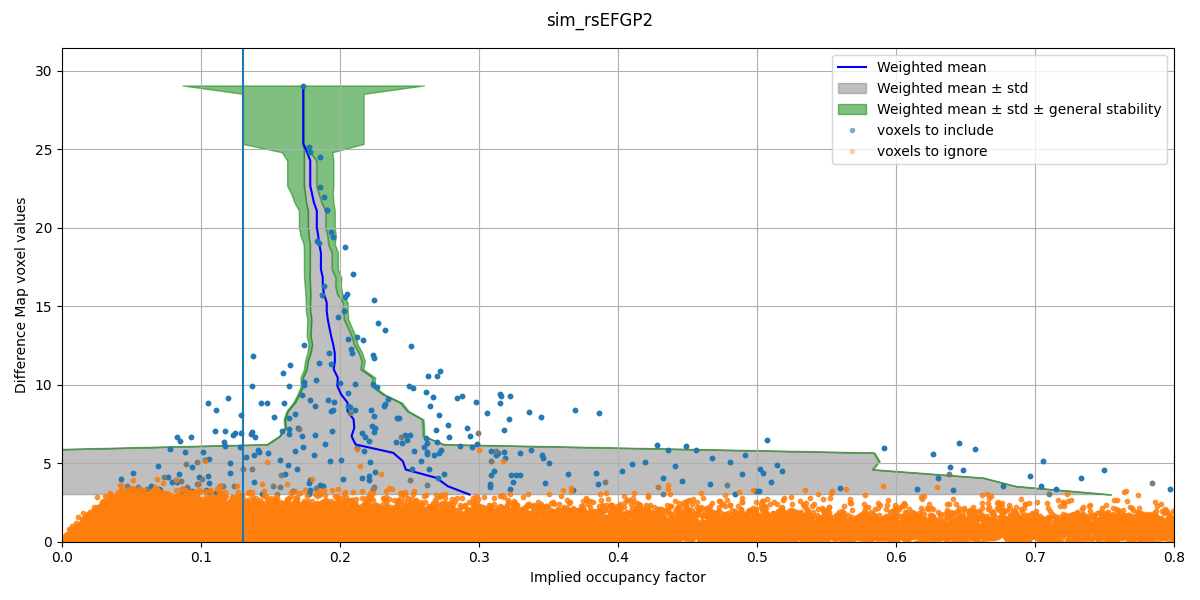

In [99]:
import matplotlib.pyplot as plt
from estimation import plot_extrapolation_estimate

config["masking"]["blocking_percentile"] = 50
config["masking"]["blocking_percentile"] = 99.999
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
ax.axvline(0.13)
ax.set_xlim(0,0.8)
plt.show()


2026-01-12 16:56:34,257: logger: WARNING: Used threshold for posmask: 0.103, found 356 blobs (masking.py:133)
2026-01-12 16:56:34,262: logger: INFO: Using blobs with more than 22.00452891919375(3 A^3) voxels (masking.py:150)
2026-01-12 16:56:34,263: logger: INFO: Maximum Blob sizes found: 219 (masking.py:151)
2026-01-12 16:56:34,280: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (7, 7, 7), considering a total of 92 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-01-12 16:56:34,426: logger: INFO: Excluding 0 (0.00%) voxels from mask due to positive density within 1.5 A and above the 99.999 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-01-12 16:56:34,449: logger: INFO: Excluding an addtional 0 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:267)
2026-01-12 16:56:34,530: logger: WARNING: Excluding an add

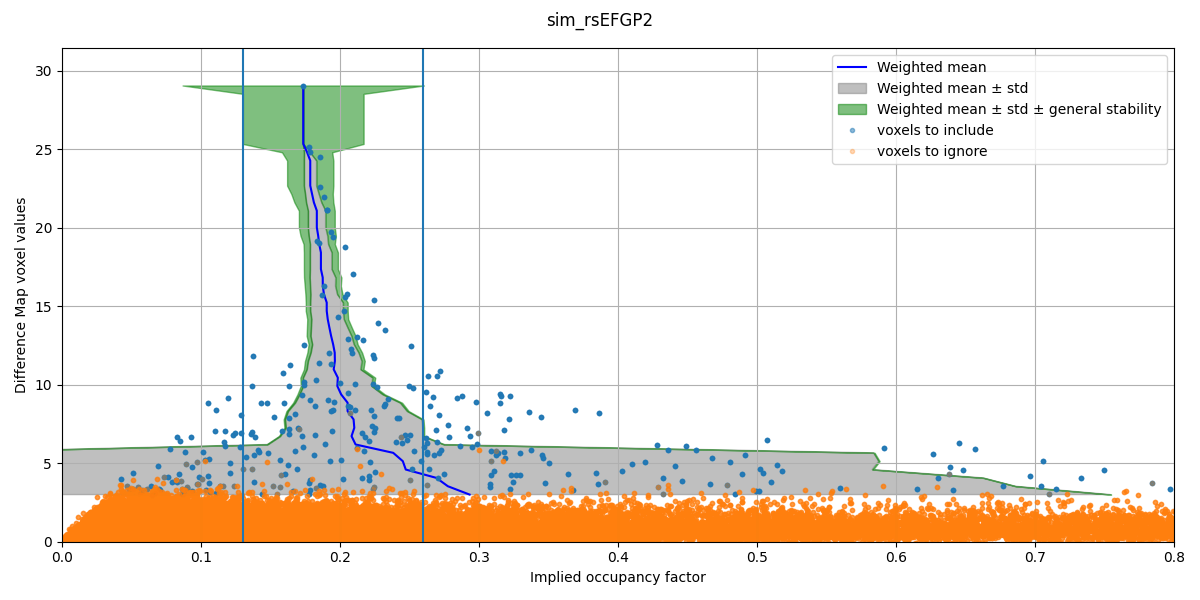

In [100]:
import matplotlib.pyplot as plt
from estimation import plot_extrapolation_estimate

config["masking"]["blocking_percentile"] = 50
config["masking"]["blocking_percentile"] = 99.999
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
ax.axvline(0.13)
ax.axvline(0.26,)
ax.set_xlim(0,0.8)
plt.show()

/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_40569/2056393411.py:5: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np


interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…

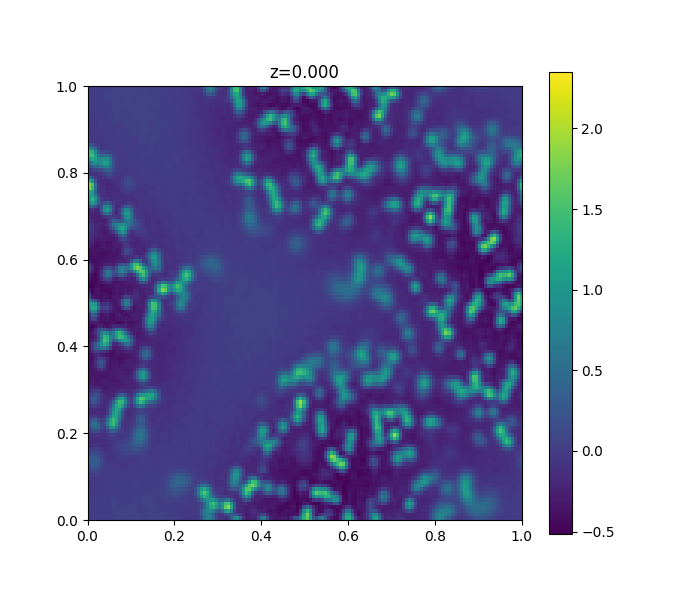

interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…

TypeError: cannot unpack non-iterable Figure object

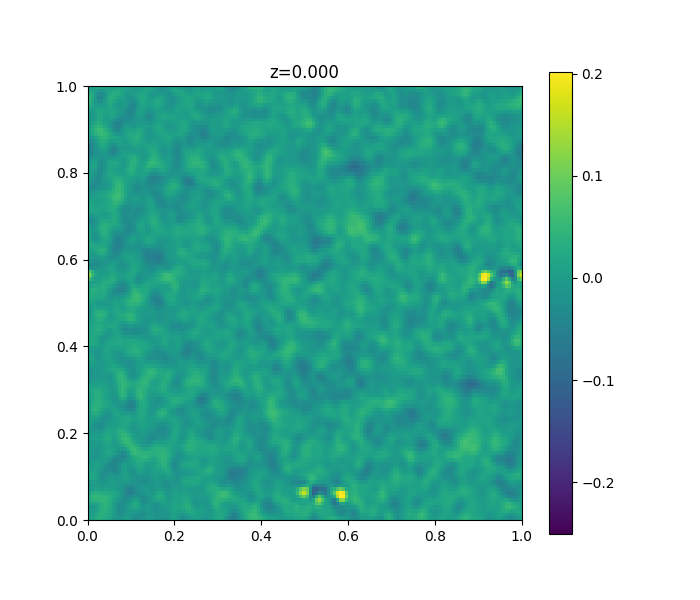

In [101]:
from plotting3d import slice_3d
%matplotlib widget
diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
pseudo_occupancy = -diffmap_np / map_dark_np
err = np.logical_and(np.abs(diffmap_np)>0.05, pseudo_occupancy>0.81)
_ =slice_3d(map_dark_np)
plt.show()
fig, ax =slice_3d(diffmap_np, )
plt.show()
fig, ax =slice_3d(diffmap_np, imkwargs={"cmap":"grey"})
_ =slice_3d(err, fig=fig, ax=ax, imkwargs=({"cmap":"Greens", "alpha":0.5}))

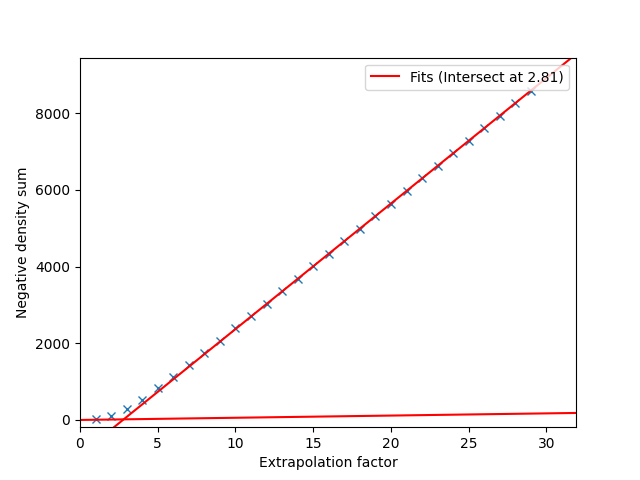

In [ ]:
# from alternative_methods import plot_negative_density_trends, _calculate_negative_density_trends
from alternative_methods import nse_analysis

fig, ax = nse_analysis(diffmap, map_dark, inclusion_mask, )

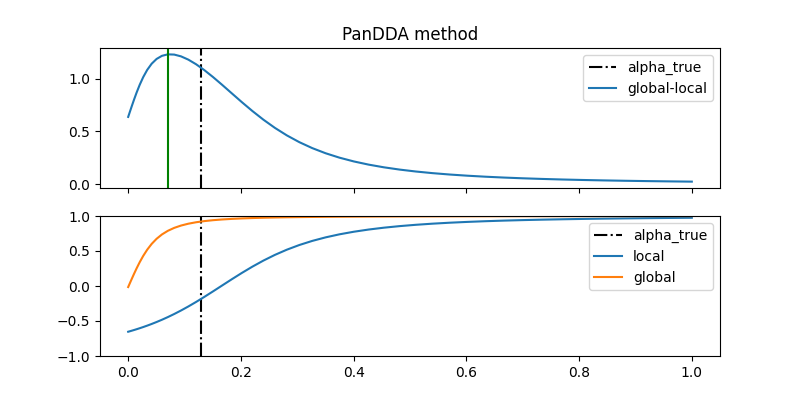

In [28]:
# /Users/sbielfel/Nextcloud2/time_resolved/X8_runs/alternative_methods.py
from alternative_methods import plot_pandda_results, _calculate_pandda
pandda_dict = _calculate_pandda(diffmap_np, map_dark_np, inclusion_mask)
alpha = 0.13
fig, axs = plot_pandda_results(pandda_dict, alpha)